## Logistic Regression

Logistic regression is a fundamental supervised machine learning algorithm used for binary classification (predicting one of two outcomes, like Yes/No or 0/1).

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
df=sns.load_dataset('titanic')

In [86]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [87]:
df=df[['survived','age','fare','sex']]

#### PreProcess

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   age       714 non-null    float64
 2   fare      891 non-null    float64
 3   sex       891 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 28.0+ KB


In [89]:
df.describe()

,survived,age,fare
count,891.000000,714.000000,891.000000
mean,0.383838,29.699118,32.204208
std,0.486592,14.526497,49.693429
min,0.000000,0.420000,0.000000
25%,0.000000,20.125000,7.910400
50%,0.000000,28.000000,14.454200
75%,1.000000,38.000000,31.000000
max,1.000000,80.000000,512.329200


In [90]:
df.isnull().sum()

,0
survived,0
age,177
fare,0
sex,0


In [91]:
df.dropna()

,survived,age,fare,sex
0,0,22.0,7.2500,male
1,1,38.0,71.2833,female
2,1,26.0,7.9250,female
3,1,35.0,53.1000,female
4,0,35.0,8.0500,male
...,...,...,...,...
885,0,39.0,29.1250,female
886,0,27.0,13.0000,male
887,1,19.0,30.0000,female
889,1,26.0,30.0000,male


In [92]:
df['is_female']=(df['sex']=='female').astype(int)

In [93]:
df['is_male']=(df['sex']=='male').astype(int)

In [94]:
df = df.drop('sex', axis=1)

In [95]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
886,True
887,False
888,False
889,False


In [96]:
df.isnull().sum()

,0
survived,0
age,177
fare,0
is_female,0
is_male,0


In [97]:
df.dropna(inplace=True)

In [98]:
df.isnull().sum()

,0
survived,0
age,0
fare,0
is_female,0
is_male,0


In [99]:
df = df.drop_duplicates()

### model build

In [100]:
X = df.drop('survived', axis=1)
y = df['survived']

In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [102]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

### S-Curve

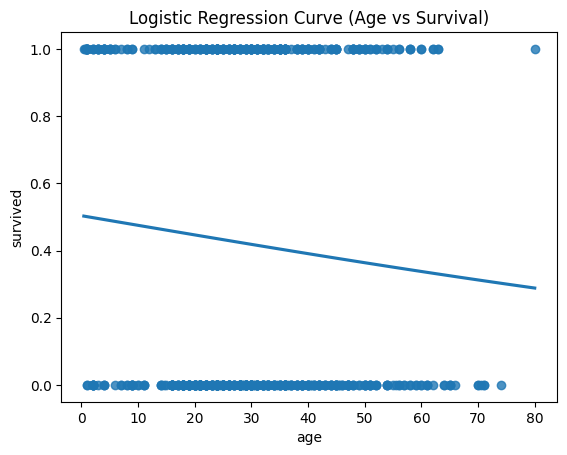

In [103]:
sns.regplot(x='age', y='survived', data=df,
            logistic=True, ci=None)

plt.title("Logistic Regression Curve (Age vs Survival)")
plt.show()

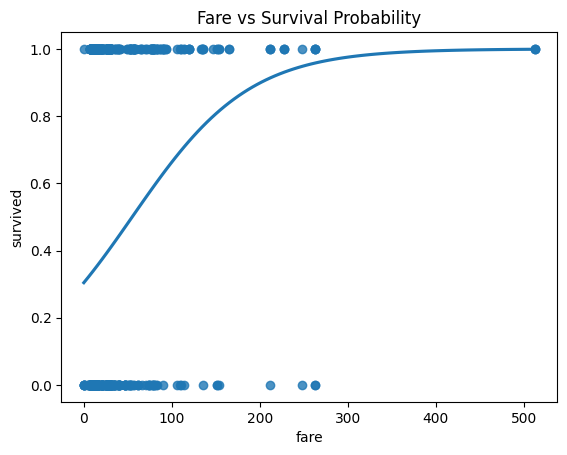

In [104]:
sns.regplot(x='fare', y='survived', data=df,
            logistic=True, ci=None)

plt.title("Fare vs Survival Probability")
plt.show()

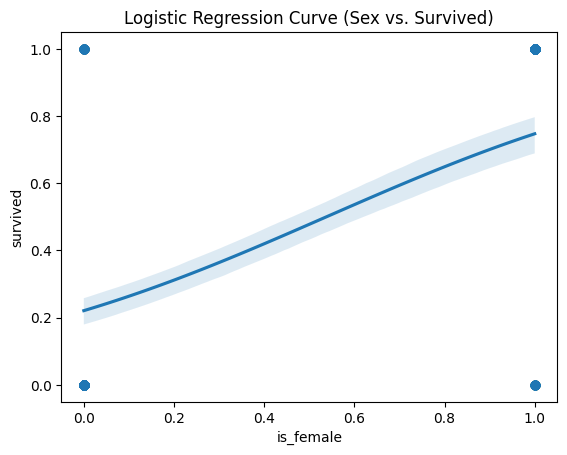

In [114]:
sns.regplot(x="is_female", y="survived", data=df, logistic=True)
plt.title("Logistic Regression Curve (Sex vs. Survived)")
plt.show()

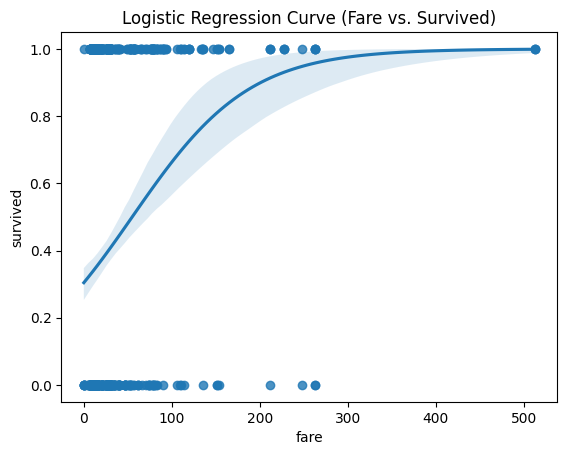

In [115]:
sns.regplot(x="fare", y="survived", data=df, logistic=True)
plt.title("Logistic Regression Curve (Fare vs. Survived)")
plt.show()

In [105]:
print(df.dtypes)

survived       int64
age          float64
fare         float64
is_female      int64
is_male        int64
dtype: object


In [106]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7910447761194029

Confusion Matrix:
 [[63 13]
 [15 43]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.83      0.82        76
           1       0.77      0.74      0.75        58

    accuracy                           0.79       134
   macro avg       0.79      0.79      0.79       134
weighted avg       0.79      0.79      0.79       134



In [107]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(comparison.head(20))

     Actual  Predicted
467       0          0
203       0          0
638       0          1
851       0          0
353       0          0
469       1          1
399       1          1
253       0          0
699       0          0
115       0          0
104       0          0
339       0          0
456       0          0
281       0          0
268       1          1
83        0          0
71        0          1
829       1          1
386       0          0
199       0          1


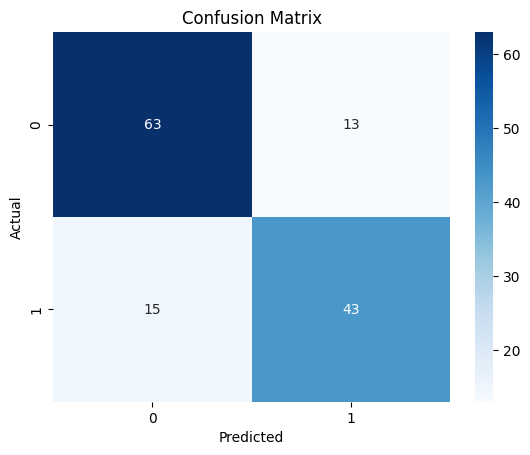

In [108]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(comparison['Actual'], comparison['Predicted'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [109]:
prediction=model.predict(X)

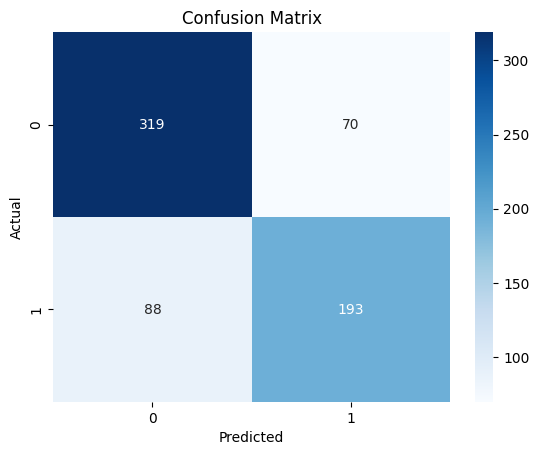

In [110]:
cm = confusion_matrix(y,prediction)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [111]:
new_passengers = pd.DataFrame({
    'age': [20, 22],
    'fare': [8, 150],
    'is_female': [0, 1],
    'is_male': [1, 0]
})

In [112]:
probs = model.predict_proba(new_passengers)
print(probs)

[[0.79475568 0.20524432]
 [0.08449805 0.91550195]]


In [113]:
jack_survival = probs[0][1]
rose_survival = probs[1][1]

print("Jack survival probability:", jack_survival)
print("Rose survival probability:", rose_survival)

Jack survival probability: 0.20524432492567157
Rose survival probability: 0.9155019464944665
